# Online Retail Sales Data Analysis

## Project Overview

This project analyzes an Online Retail dataset to identify sales trends, customer behavior, product performance, and country-wise sales patterns.

In [6]:
import pandas as pd

df = pd.read_excel("/content/sample_data/Online Retail.xlsx")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [7]:
df.shape

(541909, 8)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [9]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [10]:
df['Quantity'].describe()

,Quantity
count,541909.000000
mean,9.552250
std,218.081158
min,-80995.000000
25%,1.000000
50%,3.000000
75%,10.000000
max,80995.000000


In [11]:
df['UnitPrice'].describe()

,UnitPrice
count,541909.000000
mean,4.611114
std,96.759853
min,-11062.060000
25%,1.250000
50%,2.080000
75%,4.130000
max,38970.000000


In [12]:
df['InvoiceNo'].astype(str).str.startswith('C').sum()

np.int64(9288)

In [13]:
df.duplicated().sum()

np.int64(5268)

In [14]:
(df['Quantity'] < 0).sum()

np.int64(10624)

In [15]:
(df['UnitPrice'] <= 0).sum()

np.int64(2517)

In [16]:
df[df['InvoiceNo'].astype(str).str.startswith('C')].shape

(9288, 8)

In [17]:
df['CustomerID'].isnull().mean() * 100

np.float64(24.926694334288598)

In [18]:
df_clean = df.drop_duplicates()

df_clean = df_clean[
    ~df_clean['InvoiceNo'].astype(str).str.startswith('C')
]

df_clean = df_clean[df_clean['Quantity'] > 0]

df_clean = df_clean[df_clean['UnitPrice'] > 0]

In [19]:
df_clean.shape

(524878, 8)

In [20]:
df_clean['Revenue'] = df_clean['Quantity'] * df_clean['UnitPrice']

In [21]:
df_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [22]:
df_clean['Revenue'].sum()

np.float64(10642110.804)

In [23]:
df_clean['Quantity'].sum()

np.int64(5572420)

In [24]:
df_clean['InvoiceNo'].nunique()

19960

In [25]:
df_clean['YearMonth'] = df_clean['InvoiceDate'].dt.to_period('M')

In [26]:
monthly_sales = df_clean.groupby('YearMonth')['Revenue'].sum()

monthly_sales

,Revenue
YearMonth,
2010-12,821452.730
2011-01,689811.610
2011-02,522545.560
2011-03,716215.260
2011-04,536968.491
2011-05,769296.610
2011-06,760547.010
2011-07,718076.121
2011-08,757841.380


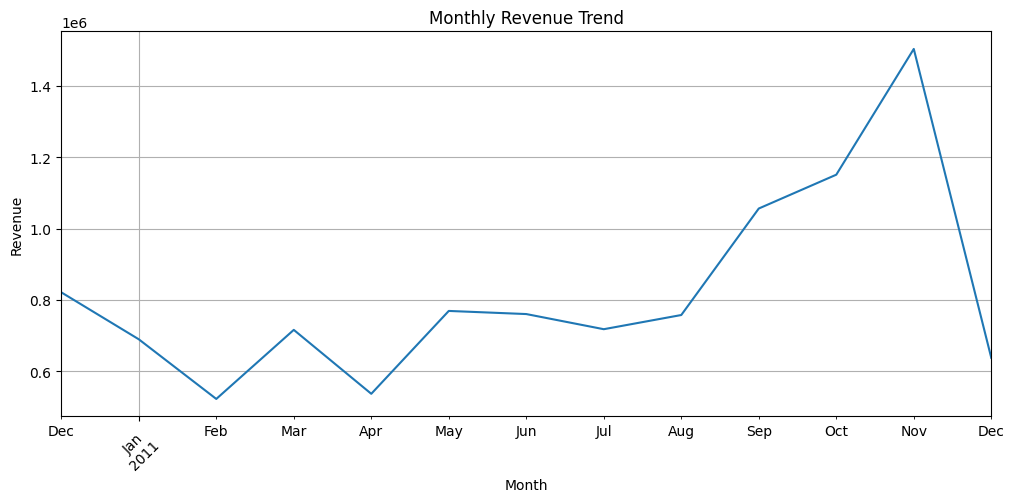

In [27]:
import matplotlib.pyplot as plt

monthly_sales.plot(kind='line', figsize=(12, 5))

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [28]:
country_sales = (
    df_clean.groupby('Country')['Revenue']
    .sum()
    .sort_values(ascending=False)
)

country_sales.head(10)

,Revenue
Country,
United Kingdom,9001744.094
Netherlands,285446.340
EIRE,283140.520
Germany,228678.400
France,209625.370
Australia,138453.810
Spain,61558.560
Switzerland,57067.600
Belgium,41196.340


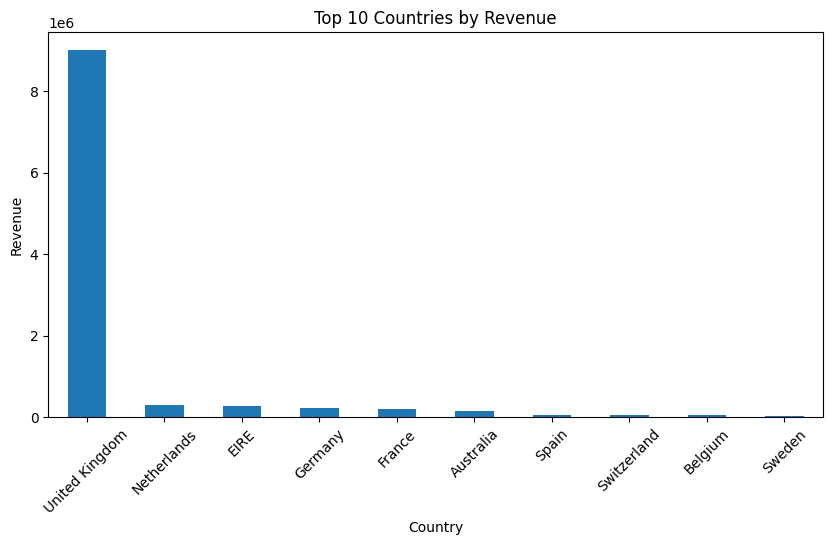

In [29]:
country_sales.head(10).plot(
    kind='bar',
    figsize=(10, 5)
)

plt.title('Top 10 Countries by Revenue')
plt.xlabel('Country')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.show()

In [30]:
country_sales.head(10)

,Revenue
Country,
United Kingdom,9001744.094
Netherlands,285446.340
EIRE,283140.520
Germany,228678.400
France,209625.370
Australia,138453.810
Spain,61558.560
Switzerland,57067.600
Belgium,41196.340


In [31]:
product_sales = (
    df_clean.groupby('Description')['Revenue']
    .sum()
    .sort_values(ascending=False)
)

product_sales.head(10)

,Revenue
Description,
DOTCOM POSTAGE,206248.77
REGENCY CAKESTAND 3 TIER,174156.54
"PAPER CRAFT , LITTLE BIRDIE",168469.60
WHITE HANGING HEART T-LIGHT HOLDER,106236.72
PARTY BUNTING,99445.23
JUMBO BAG RED RETROSPOT,94159.81
MEDIUM CERAMIC TOP STORAGE JAR,81700.92
POSTAGE,78101.88
Manual,77752.82


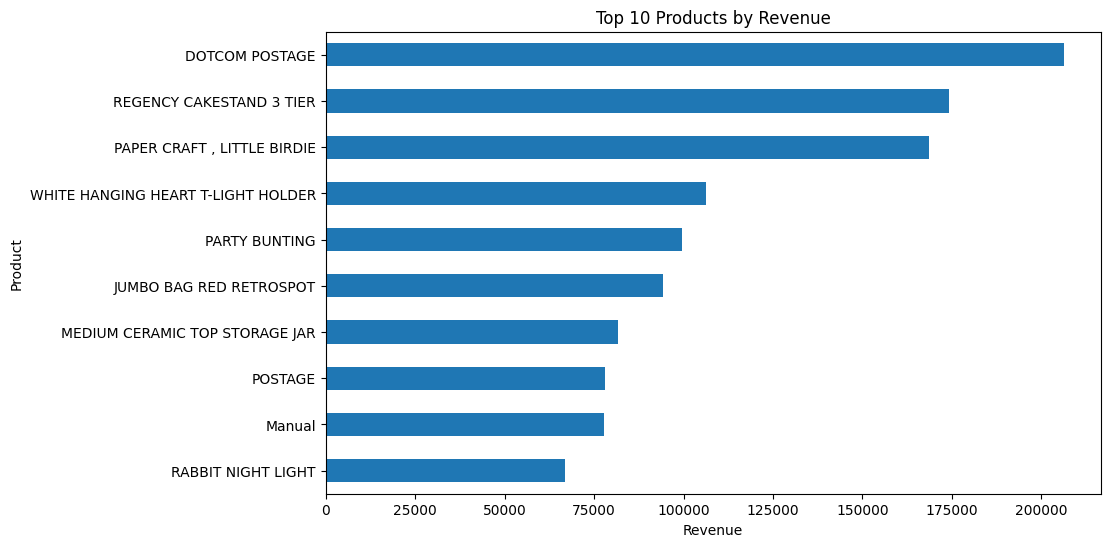

In [32]:
product_sales.head(10).sort_values().plot(
    kind='barh',
    figsize=(10,6)
)

plt.title('Top 10 Products by Revenue')
plt.xlabel('Revenue')
plt.ylabel('Product')
plt.show()

In [33]:
product_quantity = (
    df_clean.groupby('Description')['Quantity']
    .sum()
    .sort_values(ascending=False)
)

product_quantity.head(10)

,Quantity
Description,
"PAPER CRAFT , LITTLE BIRDIE",80995
MEDIUM CERAMIC TOP STORAGE JAR,78033
WORLD WAR 2 GLIDERS ASSTD DESIGNS,54951
JUMBO BAG RED RETROSPOT,48371
WHITE HANGING HEART T-LIGHT HOLDER,37872
POPCORN HOLDER,36749
PACK OF 72 RETROSPOT CAKE CASES,36396
ASSORTED COLOUR BIRD ORNAMENT,36362
RABBIT NIGHT LIGHT,30739


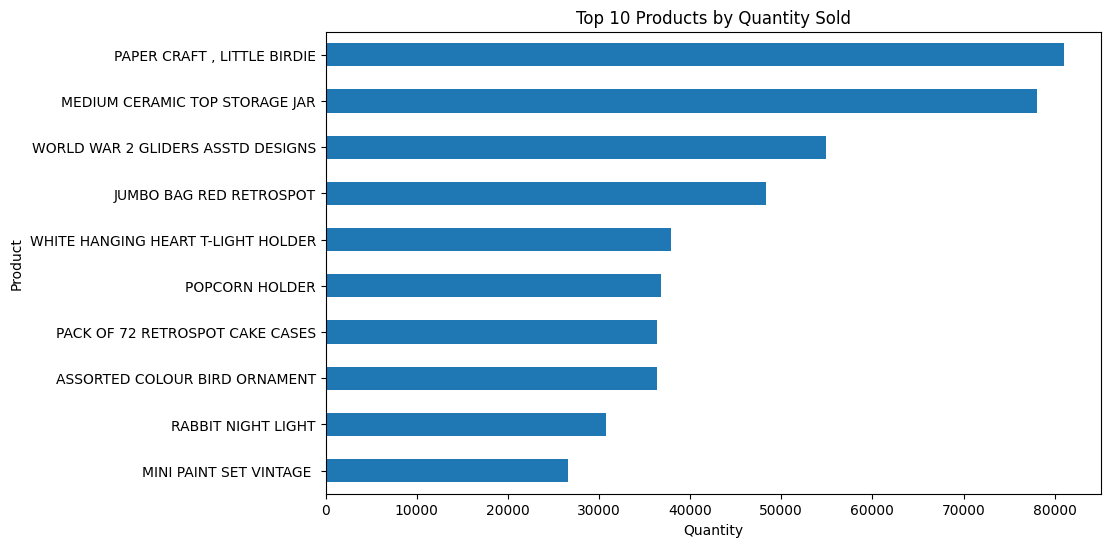

In [34]:
product_quantity.head(10).sort_values().plot(
    kind='barh',
    figsize=(10,6)
)

plt.title('Top 10 Products by Quantity Sold')
plt.xlabel('Quantity')
plt.ylabel('Product')
plt.show()

In [35]:
customer_sales = (
    df_clean.groupby('CustomerID')['Revenue']
    .sum()
    .sort_values(ascending=False)
)

customer_sales.head(10)

,Revenue
CustomerID,
14646.0,280206.02
18102.0,259657.30
17450.0,194390.79
16446.0,168472.50
14911.0,143711.17
12415.0,124914.53
14156.0,117210.08
17511.0,91062.38
16029.0,80850.84


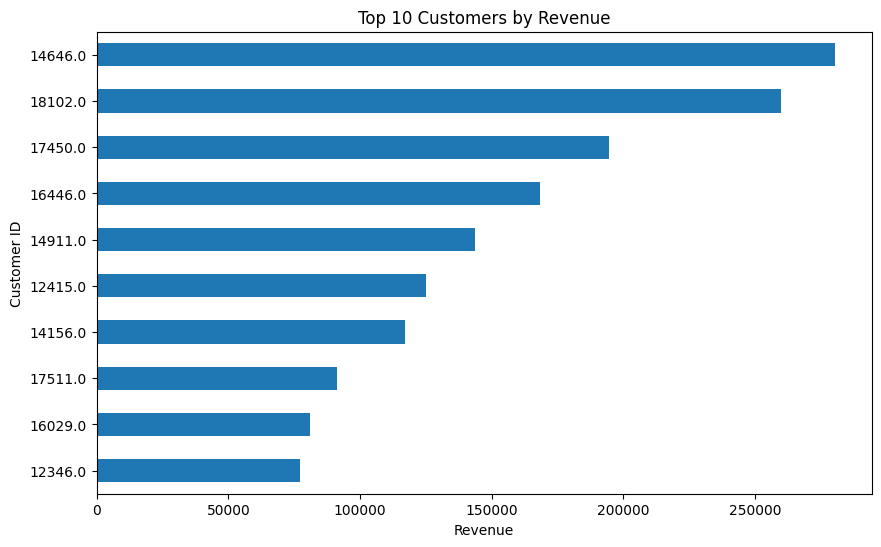

In [36]:
customer_sales.head(10).sort_values().plot(
    kind='barh',
    figsize=(10,6)
)

plt.title('Top 10 Customers by Revenue')
plt.xlabel('Revenue')
plt.ylabel('Customer ID')
plt.show()

In [37]:
total_revenue = df_clean['Revenue'].sum()
total_quantity = df_clean['Quantity'].sum()
total_orders = df_clean['InvoiceNo'].nunique()

average_order_value = total_revenue / total_orders

print("Total Revenue:", total_revenue)
print("Total Quantity Sold:", total_quantity)
print("Total Orders:", total_orders)
print("Average Order Value:", average_order_value)

Total Revenue: 10642110.804
Total Quantity Sold: 5572420
Total Orders: 19960
Average Order Value: 533.1718839679359


In [38]:
best_month = monthly_sales.idxmax()
best_month_revenue = monthly_sales.max()

worst_month = monthly_sales.idxmin()
worst_month_revenue = monthly_sales.min()

print("Best Month:", best_month)
print("Best Month Revenue:", best_month_revenue)

print("Worst Month:", worst_month)
print("Worst Month Revenue:", worst_month_revenue)

Best Month: 2011-11
Best Month Revenue: 1503866.78
Worst Month: 2011-02
Worst Month Revenue: 522545.56


In [39]:
monthly_orders = (
    df_clean.groupby('YearMonth')['InvoiceNo']
    .nunique()
)

monthly_orders

,InvoiceNo
YearMonth,
2010-12,1559
2011-01,1086
2011-02,1100
2011-03,1454
2011-04,1246
2011-05,1681
2011-06,1533
2011-07,1475
2011-08,1361


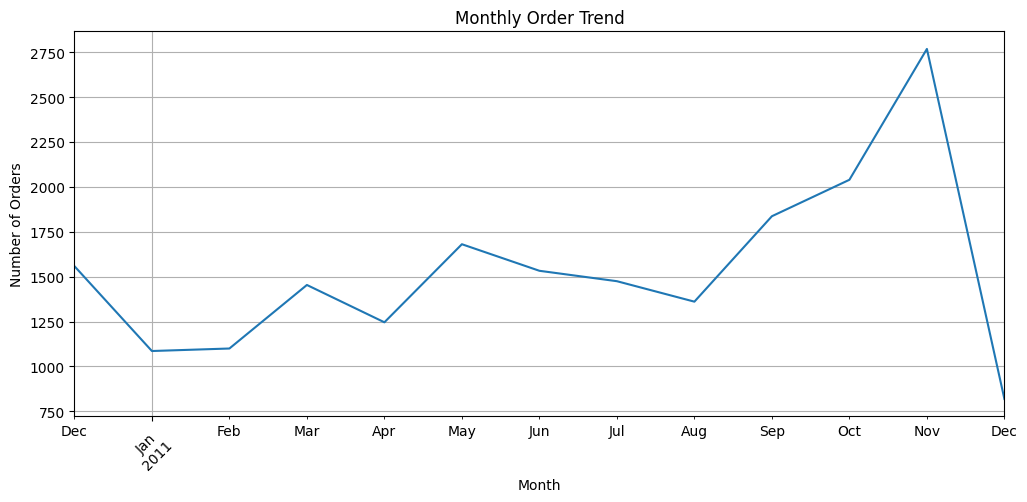

In [40]:
monthly_orders.plot(
    kind='line',
    figsize=(12,5)
)

plt.title('Monthly Order Trend')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [41]:
country_orders = (
    df_clean.groupby('Country')['InvoiceNo']
    .nunique()
    .sort_values(ascending=False)
)

country_orders.head(10)

,InvoiceNo
Country,
United Kingdom,18019
Germany,457
France,392
EIRE,288
Belgium,98
Netherlands,94
Spain,90
Portugal,58
Australia,57


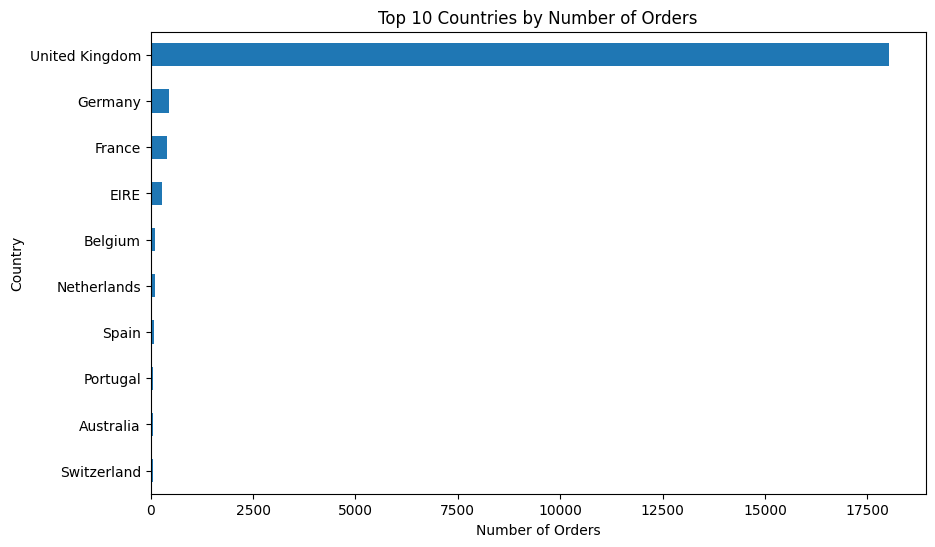

In [42]:
country_orders.head(10).sort_values().plot(
    kind='barh',
    figsize=(10,6)
)

plt.title('Top 10 Countries by Number of Orders')
plt.xlabel('Number of Orders')
plt.ylabel('Country')
plt.show()

In [43]:
print("========== FINAL BUSINESS INSIGHTS ==========")

print("\n1. Total Revenue:")
print(f"£{df_clean['Revenue'].sum():,.2f}")

print("\n2. Total Quantity Sold:")
print(f"{df_clean['Quantity'].sum():,}")

print("\n3. Total Orders:")
print(f"{df_clean['InvoiceNo'].nunique():,}")

print("\n4. Top Country by Revenue:")
print(country_sales.idxmax(), f"£{country_sales.max():,.2f}")

print("\n5. Top Country by Number of Orders:")
print(country_orders.idxmax(), country_orders.max())

print("\n6. Top Product by Revenue:")
print(product_sales.idxmax(), f"£{product_sales.max():,.2f}")

print("\n7. Best Sales Month:")
print(monthly_sales.idxmax(), f"£{monthly_sales.max():,.2f}")

print("\n8. Lowest Sales Month:")
print(monthly_sales.idxmin(), f"£{monthly_sales.min():,.2f}")

========== FINAL BUSINESS INSIGHTS ==========

1. Total Revenue:
£10,642,110.80

2. Total Quantity Sold:
5,572,420

3. Total Orders:
19,960

4. Top Country by Revenue:
United Kingdom £9,001,744.09

5. Top Country by Number of Orders:
United Kingdom 18019

6. Top Product by Revenue:
DOTCOM POSTAGE £206,248.77

7. Best Sales Month:
2011-11 £1,503,866.78

8. Lowest Sales Month:
2011-02 £522,545.56


## Final Business Insights

1. The business generated a total revenue of £10.64 million from 19,960 orders.

2. A total of 5.57 million units were sold during the analyzed period.

3. The United Kingdom was the strongest market, generating £9.00 million in revenue and accounting for 18,019 orders.

4. DOTCOM POSTAGE was the highest-revenue product, generating £206,248.77.

5. November 2011 was the best-performing month, with revenue of £1.50 million.

6. February 2011 recorded the lowest monthly revenue, at £522,545.56.

7. The analysis shows that the United Kingdom was the primary contributor to both revenue and order volume.

8. Monthly revenue fluctuated considerably, indicating opportunities to investigate the factors behind high- and low-performing months.

## Conclusion

The Online Retail Sales Data Analysis provided a detailed understanding of the company's sales performance, order volume, product performance, and country-wise revenue.

The analysis shows that the United Kingdom was the strongest market, contributing the majority of the revenue and orders. November 2011 recorded the highest monthly revenue, while February 2011 recorded the lowest.

Overall, the analysis demonstrates how Python, Pandas, and data visualization can be used to transform raw retail transaction data into meaningful business insights that can support data-driven decision-making.